In [1]:
#kutubxonalarni yuklaymiz
import pandas as pd
import numpy as np

In [3]:
#datasetni yuklab olamiz
df = pd.read_csv('https://raw.githubusercontent.com/botirTurgonboyev/ML/refs/heads/main/China_GDP.csv')
df.head(10)

,Unnamed: 0,Year,Value
0,0,1960,5.918412e+10
1,1,1961,4.955705e+10
2,2,1962,4.668518e+10
3,3,1963,5.009730e+10
4,4,1964,5.906225e+10
5,5,1965,6.970915e+10
6,6,1966,7.587943e+10
7,7,1967,7.205703e+10
8,8,1968,6.999350e+10
9,9,1969,7.871882e+10


In [4]:
#yil va YaIM ustunlarini ajratib olamiz

x_data, y_data = (df['Year'].values, df['Value'].values)

In [5]:
x_data

array([1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014])

In [6]:
y_data

array([5.91841165e+10, 4.95570502e+10, 4.66851785e+10, 5.00973033e+10,
       5.90622549e+10, 6.97091531e+10, 7.58794348e+10, 7.20570286e+10,
       6.99934979e+10, 7.87188205e+10, 9.15062113e+10, 9.85620238e+10,
       1.12159814e+11, 1.36769878e+11, 1.42254742e+11, 1.61162492e+11,
       1.51627687e+11, 1.72349014e+11, 1.48382112e+11, 1.76856525e+11,
       1.89649992e+11, 1.94369049e+11, 2.03549627e+11, 2.28950201e+11,
       2.58082147e+11, 3.07479586e+11, 2.98805793e+11, 2.71349773e+11,
       3.10722214e+11, 3.45957486e+11, 3.58973230e+11, 3.81454704e+11,
       4.24934066e+11, 4.42874596e+11, 5.62261130e+11, 7.32032045e+11,
       8.60844098e+11, 9.58159425e+11, 1.02527690e+12, 1.08944711e+12,
       1.20526068e+12, 1.33223472e+12, 1.46190649e+12, 1.64992872e+12,
       1.94174560e+12, 2.26859890e+12, 2.72978403e+12, 3.52309431e+12,
       4.55843107e+12, 5.05941974e+12, 6.03965851e+12, 7.49243210e+12,
       8.46162316e+12, 9.49060260e+12, 1.03548317e+13])

In [7]:
#vizualizatsiya uchun kutubxonalarni chaqirib olamiz
import matplotlib.pyplot as plt
import seaborn as sns
#matplotlib inline

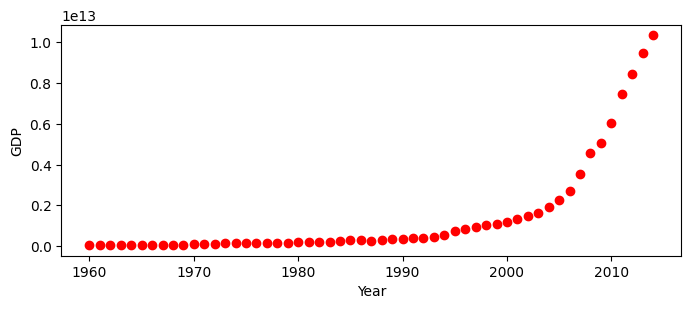

In [8]:
plt.figure(figsize=(8, 3))
plt.plot(x_data, y_data, 'ro')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

In [9]:
# x va y larni 0 va 1 oralig'iga tushirib olamiz
x = np.asanyarray(df['Year']/df.Year.max())
y = np.asanyarray(df['Value']/df.Value.max())

In [10]:
df.shape

(55, 3)

Malumot ozligi uchun train va test setga ajratmadik

In [12]:
#model
from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()

LR_model.fit(x.reshape(-1, 1), y)

LinearRegression()

In [13]:
y_LR = LR_model.predict(x.reshape(-1, 1))

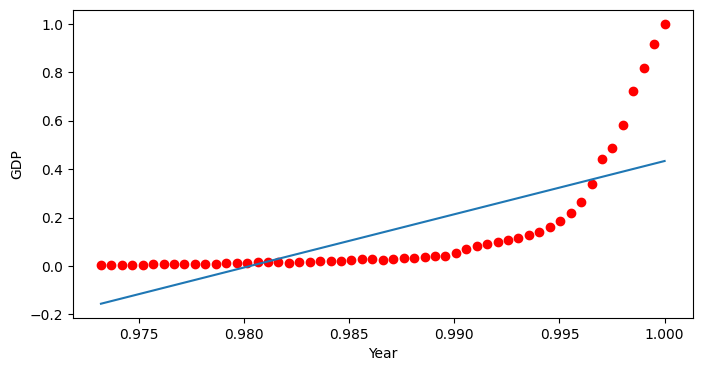

In [14]:
#Grafik yordamida tekshiramiz
plt.figure(figsize=(8, 4))
plt.plot(x, y, 'ro')
plt.plot(x, y_LR)
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error

print('MAE: ', mean_absolute_error(y_LR, y))

MAE:  0.12657979406214762


In [16]:
from sklearn.metrics import r2_score

print('R2: ', r2_score(y_LR, y))

R2:  0.0914967875299908


## Polynomial regression

In [17]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5, include_bias=False)
poly_x = poly.fit_transform(x.reshape(-1, 1))


In [18]:
LR_model.fit(poly_x, y)

LinearRegression()

In [19]:
y_h2 = LR_model.predict(poly_x)

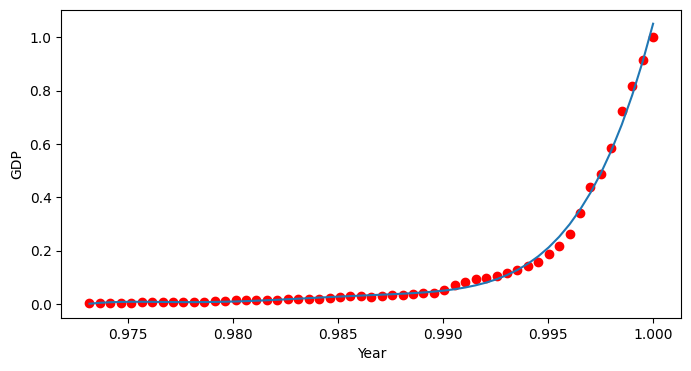

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(x, y, 'ro')
plt.plot(x, y_h2)
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

In [21]:
print("MAE:", mean_absolute_error(y_h2,y))

MAE: 0.009253921906050316


In [22]:
print("R2:", r2_score(y_h2,y))

R2: 0.995950303183176
